# FraudNet

DL model for IEEE-CIS Fraud Detection. Run in Colab on a T4 GPU.

## Setup

In [1]:
from google.colab import files

!rm -f kaggle.json
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c ieee-fraud-detection
!unzip -q -o ieee-fraud-detection.zip -d data/
!pip install -q wandb

Saving kaggle.json to kaggle.json
100% 118M/118M [00:01<00:00, 86.8MB/s]



In [2]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import wandb
from sklearn.metrics import average_precision_score, f1_score, log_loss, roc_auc_score
from sklearn.preprocessing import QuantileTransformer
from torch.utils.data import DataLoader, TensorDataset

device = "cuda" if torch.cuda.is_available() else "cpu"
wandb.login()

/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kov-koalla (kov-koalla-kyiv-school-of-economics) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Data

In [3]:
def load(split):
    df = pd.read_csv(f"data/{split}_transaction.csv")
    identity = pd.read_csv(f"data/{split}_identity.csv")
    df = df.merge(identity, on="TransactionID", how="left")
    df.columns = df.columns.str.replace("-", "_")

    float_cols = df.select_dtypes("float64").columns
    df[float_cols] = df[float_cols].astype(np.float32)
    df = df.copy()

    df["DT_day"] = df.TransactionDT // 86400
    df["DT_hour"] = df.TransactionDT // 3600 % 24
    df["DT_dow"] = df.DT_day % 7
    df["TransactionAmt_decimal"] = np.round(df.TransactionAmt % 1 * 1000)
    for c in ["D1", "D2", "D4", "D10", "D11", "D15"]:
        df[c + "_detrended"] = df[c] - df.TransactionDT / 86400
    return df


train_df = load("train")
test_df = load("test")
train_mask = train_df.DT_day <= 122
val_mask = train_df.DT_day >= 153
print(train_mask.sum(), val_mask.sum())

420066 85430


In [4]:
cat_cols = ["ProductCD", "card1", "card2", "card3", "card4", "card5", "card6",
            "addr1", "addr2", "P_emaildomain", "R_emaildomain", "DeviceType", "DeviceInfo",
            "DT_hour", "DT_dow"]
cat_cols += [f"M{i}" for i in range(1, 10)]
cat_cols += [f"id_{i}" for i in range(12, 39)]

num_cols = ["TransactionAmt", "TransactionAmt_decimal", "dist1", "dist2",
            "C1", "C2", "C3", "C5", "C6", "C8", "C9", "C11", "C13", "C14",
            "D3", "D5", "D6", "D7", "D8", "D9", "D12", "D13", "D14",
            "D1_detrended", "D2_detrended", "D4_detrended", "D10_detrended", "D11_detrended", "D15_detrended"]
num_cols += [f"V{i}" for i in range(1, 340)]
num_cols += [f"id_{i:02d}" for i in range(1, 12)]

freq_cols = ["card1", "addr1", "P_emaildomain", "DeviceInfo"]
print(len(cat_cols), len(num_cols) + len(freq_cols))

51 383


In [5]:
class Prep:
    def fit(self, df):
        self.freq = {}
        for c in freq_cols:
            self.freq[c] = df[c].value_counts(dropna=False)

        self.codes = {}
        for c in cat_cols:
            counts = df[c].value_counts()
            kept = counts[counts >= 10].index
            self.codes[c] = {value: i + 2 for i, value in enumerate(kept)}
        self.sizes = [len(self.codes[c]) + 2 for c in cat_cols]

        self.qt = QuantileTransformer(n_quantiles=1000, output_distribution="normal", subsample=200_000, random_state=0)
        self.qt.fit(self.numeric(df))
        return self

    def numeric(self, df):
        x = df[num_cols].copy()
        for c in freq_cols:
            x[c + "_freq"] = df[c].map(self.freq[c]).fillna(0)
        return x.to_numpy(np.float32)

    def transform(self, df):
        x_num = self.qt.transform(self.numeric(df)).astype(np.float32)
        x_cat = np.zeros((len(df), len(cat_cols)), dtype=np.int64)
        for i, c in enumerate(cat_cols):
            codes = df[c].map(self.codes[c]).fillna(1)
            codes[df[c].isna()] = 0
            x_cat[:, i] = codes
        return x_num, x_cat

## Model

In [6]:
class NanFill(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.fill = nn.Parameter(torch.zeros(n_features))

    def forward(self, x):
        return torch.where(torch.isnan(x), self.fill, x)


class FraudNet(nn.Module):
    def __init__(self, n_num, sizes, hidden=512, dropout=0.2):
        super().__init__()
        self.nan_fill = NanFill(n_num)
        self.embs = nn.ModuleList()
        for n in sizes:
            self.embs.append(nn.Embedding(n, 8))

        n_in = n_num + 8 * len(sizes)
        self.layers = nn.Sequential(
            nn.Linear(n_in, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden // 2, hidden // 4),
            nn.BatchNorm1d(hidden // 4),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden // 4, 1),
        )

    def forward(self, x_num, x_cat):
        parts = [self.nan_fill(x_num)]
        for i, emb in enumerate(self.embs):
            parts.append(emb(x_cat[:, i]))
        x = torch.cat(parts, dim=1)
        return self.layers(x).squeeze(1)

## AdamW

In [7]:
class AdamW(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=1e-2):
        defaults = dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr = group["lr"]
            beta1, beta2 = group["betas"]
            eps = group["eps"]
            wd = group["weight_decay"]

            for p in group["params"]:
                if p.grad is None:
                    continue
                g = p.grad
                state = self.state[p]
                if len(state) == 0:
                    state["t"] = 0
                    state["m"] = torch.zeros_like(p)
                    state["v"] = torch.zeros_like(p)

                state["t"] += 1
                p *= 1 - lr * wd
                state["m"] = beta1 * state["m"] + (1 - beta1) * g
                state["v"] = beta2 * state["v"] + (1 - beta2) * g ** 2
                m_hat = state["m"] / (1 - beta1 ** state["t"])
                v_hat = state["v"] / (1 - beta2 ** state["t"])
                p -= lr * m_hat / (v_hat.sqrt() + eps)

## Training

In [8]:
def predict(model, x_num, x_cat):
    loader = DataLoader(TensorDataset(torch.tensor(x_num), torch.tensor(x_cat)), batch_size=8192)
    model.eval()
    preds = []
    with torch.no_grad():
        for xb_num, xb_cat in loader:
            logits = model(xb_num.to(device), xb_cat.to(device))
            preds.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(preds)


def train(name, train_data, val_data, sizes, lr=2e-3, dropout=0.2, weight_decay=1e-2, hidden=512, epochs=20):
    torch.manual_seed(42)
    x_num, x_cat, y = train_data
    dataset = TensorDataset(torch.tensor(x_num), torch.tensor(x_cat), torch.tensor(y))
    train_loader = DataLoader(dataset, batch_size=2048, shuffle=True, drop_last=True)

    model = FraudNet(x_num.shape[1], sizes, hidden, dropout).to(device)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.8)
    criterion = nn.BCEWithLogitsLoss()

    config = dict(lr=lr, dropout=dropout, weight_decay=weight_decay, hidden=hidden, epochs=epochs)
    wandb.init(project="ieee-fraud-detection", group="dl", name=name, config=config)
    wandb.watch(model, log="gradients", log_freq=100)

    history = {"train_loss": [], "val_loss": [], "val_auc": []}
    grad_norms = {"nan_fill": [], "linear1": [], "linear2": [], "linear3": [], "output": []}
    best_auc = 0
    best_epoch = epochs
    best_state = None
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0
        for xb_num, xb_cat, yb in train_loader:
            logits = model(xb_num.to(device), xb_cat.to(device))
            loss = criterion(logits, yb.to(device))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        grad_norms["nan_fill"].append(model.nan_fill.fill.grad.norm().item())
        grad_norms["linear1"].append(model.layers[0].weight.grad.norm().item())
        grad_norms["linear2"].append(model.layers[4].weight.grad.norm().item())
        grad_norms["linear3"].append(model.layers[8].weight.grad.norm().item())
        grad_norms["output"].append(model.layers[12].weight.grad.norm().item())

        train_loss = epoch_loss / len(train_loader)
        history["train_loss"].append(train_loss)
        wandb.log({"epoch": epoch, "train_loss": train_loss, "lr": optimizer.param_groups[0]["lr"]})
        scheduler.step()

        if val_data is None:
            print(epoch, round(train_loss, 4))
            continue

        val_pred = predict(model, val_data[0], val_data[1])
        val_loss = log_loss(val_data[2], val_pred)
        val_auc = roc_auc_score(val_data[2], val_pred)
        val_pr_auc = average_precision_score(val_data[2], val_pred)
        history["val_loss"].append(val_loss)
        history["val_auc"].append(val_auc)
        wandb.log({"epoch": epoch, "val_loss": val_loss, "val_auc": val_auc, "val_pr_auc": val_pr_auc})
        print(epoch, round(train_loss, 4), round(val_loss, 4), round(val_auc, 4))

        if val_auc > best_auc:
            best_auc = val_auc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs == 3:
                break

    wandb.finish()
    if best_state is not None:
        model.load_state_dict(best_state)
    return {"model": model, "history": history, "grad_norms": grad_norms, "best_epoch": best_epoch, "best_auc": best_auc}

## Experiments

In [9]:
tr = train_df[train_mask]
va = train_df[val_mask]
prep = Prep().fit(tr)
x_num_tr, x_cat_tr = prep.transform(tr)
x_num_va, x_cat_va = prep.transform(va)
y_tr = tr.isFraud.to_numpy(np.float32)
y_va = va.isFraud.to_numpy(np.float32)
train_data = (x_num_tr, x_cat_tr, y_tr)
val_data = (x_num_va, x_cat_va, y_va)

In [10]:
configs = {
    "base": {},
    "lr-low": {"lr": 1e-3},
    "lr-high": {"lr": 4e-3},
    "dropout-high": {"dropout": 0.4},
    "small-net": {"hidden": 256},
    "wd-high": {"weight_decay": 1e-1},
}
results = {}
rows = []
for name, params in configs.items():
    results[name] = train(name, train_data, val_data, prep.sizes, **params)
    rows.append({"run": name, "best_epoch": results[name]["best_epoch"], "val_auc": results[name]["best_auc"]})

tuning = pd.DataFrame(rows).sort_values("val_auc", ascending=False)
tuning

1 0.1226 0.1254 0.8633
2 0.091 0.1278 0.8695
3 0.0837 0.1224 0.8715
4 0.0778 0.1347 0.8763
5 0.0729 0.1282 0.8749
6 0.0683 0.1197 0.8699
7 0.0646 0.1205 0.8745


epoch,▁▁▂▂▃▃▅▅▆▆▇▇██
lr,█▆▅▃▂▂▁
train_loss,█▄▃▃▂▁▁
val_auc,▁▄▅█▇▅▇
val_loss,▄▅▂█▅▁▁
val_pr_auc,▅▅▅▅▁▅█
epoch,7
lr,0.00052
train_loss,0.06459
val_auc,0.8745
val_loss,0.12051


1 0.1394 0.1195 0.8662
2 0.0922 0.125 0.8675
3 0.0856 0.1344 0.8742
4 0.0805 0.1381 0.8726
5 0.0755 0.1294 0.8728
6 0.0712 0.1298 0.8621


epoch,▁▁▂▂▄▄▅▅▇▇██
lr,█▆▄▃▂▁
train_loss,█▃▂▂▁▁
val_auc,▃▄█▇▇▁
val_loss,▁▃▇█▅▅
val_pr_auc,█▇█▇▅▁
epoch,6
lr,0.00033
train_loss,0.07121
val_auc,0.86214
val_loss,0.12983


wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


...

1 0.1497 0.1231 0.8646
2 0.0928 0.1285 0.8674
3 0.0864 0.1234 0.8603
4 0.0805 0.1178 0.8774
5 0.0757 0.1284 0.873
6 0.0719 0.1205 0.8805
7 0.0683 0.1174 0.8787
8 0.0653 0.1244 0.8747
9 0.063 0.1327 0.8748


epoch,▁▁▂▂▃▃▄▄▅▅▅▅▆▆▇▇██
lr,█▆▅▄▃▂▂▁▁
train_loss,█▃▃▂▂▂▁▁▁
val_auc,▂▃▁▇▅█▇▆▆
val_loss,▄▆▄▁▆▂▁▄█
val_pr_auc,█▇▁▆▂█▇▄▅
epoch,9
lr,0.00034
train_loss,0.06305
val_auc,0.87484
val_loss,0.13272


1 0.1227 0.1245 0.8661
2 0.091 0.1269 0.8662
3 0.0839 0.1239 0.8764
4 0.0782 0.1338 0.8762
5 0.073 0.1276 0.8743
6 0.0686 0.117 0.8727


epoch,▁▁▂▂▄▄▅▅▇▇██
lr,█▆▄▃▂▁
train_loss,█▄▃▂▂▁
val_auc,▁▁██▇▅
val_loss,▄▅▄█▅▁
val_pr_auc,█▇▇█▁▃
epoch,6
lr,0.00066
train_loss,0.0686
val_auc,0.87267
val_loss,0.11701


,run,best_epoch,val_auc
2,lr-high,4,0.880688
4,small-net,6,0.880515
3,dropout-high,4,0.879982
5,wd-high,3,0.876399
0,base,4,0.876326
1,lr-low,3,0.874244


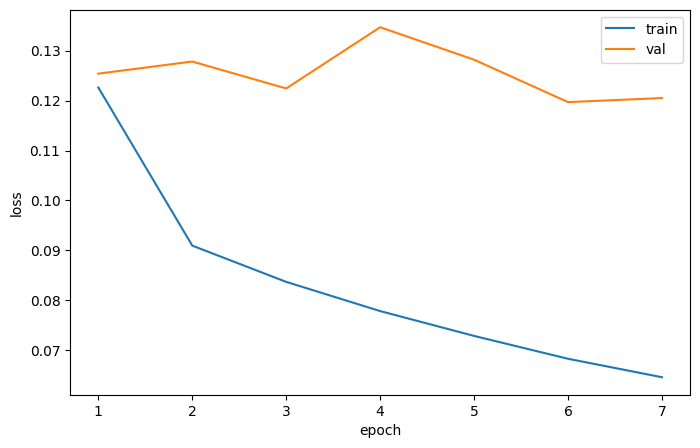

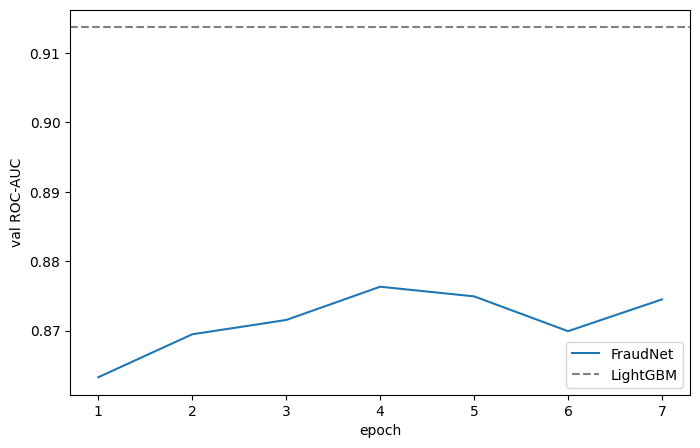

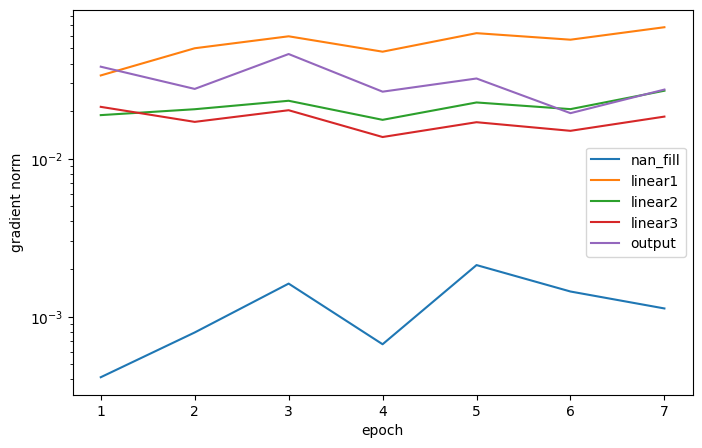

In [11]:
base = results["base"]
epochs = range(1, len(base["history"]["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, base["history"]["train_loss"], label="train")
plt.plot(epochs, base["history"]["val_loss"], label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, base["history"]["val_auc"], label="FraudNet")
plt.axhline(0.9137, color="gray", linestyle="--", label="LightGBM")
plt.xlabel("epoch")
plt.ylabel("val ROC-AUC")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
for name, values in base["grad_norms"].items():
    plt.plot(epochs, values, label=name)
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("gradient norm")
plt.legend()
plt.show()

### Best run vs LightGBM

LightGBM PR-AUC and F1 are from its baseline params.

In [12]:
best = tuning.run.iloc[0]
best_epoch = results[best]["best_epoch"]
val_pred = predict(results[best]["model"], x_num_va, x_cat_va)
print(best, best_epoch)

dl_val = {
    "roc_auc": roc_auc_score(y_va, val_pred),
    "pr_auc": average_precision_score(y_va, val_pred),
    "f1": f1_score(y_va, val_pred > 0.5),
}
lgbm_val = {"roc_auc": 0.9137, "pr_auc": 0.5634, "f1": 0.5022}
pd.DataFrame({"LightGBM": lgbm_val, "FraudNet": dl_val})

lr-high 4


,LightGBM,FraudNet
roc_auc,0.9137,0.880688
pr_auc,0.5634,0.442748
f1,0.5022,0.428443


In [13]:
val_out = va[["TransactionID", "isFraud"]].copy()
val_out["dl_score"] = val_pred
val_out.to_csv("dl_val_predictions.csv", index=False)

### Final model (all 182 days) and submission

In [14]:
final_prep = Prep().fit(train_df)
x_num_full, x_cat_full = final_prep.transform(train_df)
y_full = train_df.isFraud.to_numpy(np.float32)
full_data = (x_num_full, x_cat_full, y_full)
final = train("final", full_data, None, final_prep.sizes, epochs=best_epoch, **configs[best])

1 0.111
2 0.085
3 0.0774
4 0.0714


epoch,▁▃▆█
lr,█▅▃▁
train_loss,█▃▂▁
epoch,4
lr,0.00205
train_loss,0.07145


In [15]:
x_num_test, x_cat_test = final_prep.transform(test_df)
test_pred = predict(final["model"], x_num_test, x_cat_test)
sub = pd.DataFrame({"TransactionID": test_df.TransactionID, "isFraud": test_pred})
sub.to_csv("submission_dl.csv", index=False)
print(sub.shape, sub.isFraud.isna().sum())

(506691, 2) 0


In [16]:
!kaggle competitions submit -c ieee-fraud-detection -f submission_dl.csv -m "FraudNet"

100% 9.81M/9.81M [00:00<00:00, 27.5MB/s]
Successfully submitted to IEEE-CIS Fraud Detection

### Leaderboard

In [19]:
public = 0.915955
private = 0.884124
pd.DataFrame(
    {"LightGBM": [0.9137, 0.935025, 0.898868], "FraudNet": [dl_val["roc_auc"], public, private]},
    index=["local", "public", "private"],
)

,LightGBM,FraudNet
local,0.913700,0.880688
public,0.935025,0.915955
private,0.898868,0.884124


In [18]:
files.download("dl_val_predictions.csv")
files.download("submission_dl.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusions

- best run: lr-high (lr 0.004), epoch 4
- FraudNet vs LightGBM (ROC-AUC): local 0.881 vs 0.914, public 0.916 vs 0.935, private 0.884 vs 0.899
- FraudNet is worse everywhere, but the gap gets smaller on test: 0.033 local and 0.015 private
- loss: train loss goes down all the time, val loss stays around 0.12-0.13. So, it overfits after 1-2 epochs, early stopping stops it
- gradients are stable, no vanishing or exploding. nan_fill grads are small because only NaN cells give it a gradient
- tuning: all 6 runs are between 0.874 and 0.881, so the differences are small, can be noise with one seed
- LightGBM is still better, which is normal for tabular data